query 和 key 经过注意力评分函数是输出结果经过 softmax 运算转化为 value 的概率分布

注意力汇聚的输出就是 value 基于这些注意力权重的加权和

**掩码 Softmax 操作**

普通softmax会对全部位置计算概率
但很多场景存在无效填充位置（无意义的特殊 token，未来不可见 token 等）

1. 把超出有效长度的无效位置打分替换成极小负数
2. 再做 softmax，极小负数经过指数后几乎等于 0

In [1]:
import matplotlib.pyplot as plt

def show_heatmaps(matrices, xlabel='Query', ylabel='Key', titles=None, figsize=(2.5, 2.5), cmap='Reds'):
    """
    可视化注意力权重热力图，直观体现：每一个查询，分别给每一个键分配了多大的关注度
    Args:
        matrices: 4维张量 [画布行数, 画布列数, num_queries, num_keys]
        titles: 子图标题列表
        figsize: 单张子图尺寸
        cmap: 热力配色
    """
    num_rows, num_cols = matrices.shape[0], matrices.shape[1]
    fig, axes = plt.subplots(
        num_rows, num_cols,
        figsize=(figsize[0]*num_cols, figsize[1]*num_rows),
        sharex=True, sharey=True,
        squeeze=False
    )

    pcm = None
    for i, (row_axes, row_mats) in enumerate(zip(axes, matrices)):
        for j, (ax, mat) in enumerate(zip(row_axes, row_mats)):
            data = mat.detach().cpu().numpy()
            pcm = ax.imshow(data, cmap=cmap)
            # 仅底行显示x标签
            if i == num_rows - 1:
                ax.set_xlabel(xlabel)
            # 仅首列显示y标签
            if j == 0:
                ax.set_ylabel(ylabel)
            # 设置子图标题
            if titles is not None:
                ax.set_title(titles[j])
    # 全局色条
    fig.colorbar(pcm, shrink=0.6)
    plt.tight_layout()
    plt.show()

In [2]:
import math
import torch
import torch.nn as nn
from torch.nn import functional as F

def sequence_mask(x: torch.Tensor, valid_lens: torch.Tensor, mask_value: float = -1e6) -> torch.Tensor:
    """
    对二维张量每行做尾部掩码：索引 >= valid_len 全部填充 mask_value
    Args:
        x: shape [N, L]，N行序列，每行长度L
        valid_lens: shape [N]，每行对应的有效长度
        mask_value: 掩码填充极小值
    Returns:
        掩码后的同shape张量
    """
    n_seq, seq_len = x.shape
    # 生成位置索引 0,1,...,seq_len-1
    pos = torch.arange(seq_len, device=x.device, dtype=torch.long)
    # 广播构造掩码：[N, L]，True代表需要掩码（超出有效长度）
    mask = pos.unsqueeze(0) >= valid_lens.unsqueeze(1)
    # 原地替换掩码区域
    x = x.masked_fill(mask, mask_value)
    return x


def masked_softmax(X: torch.Tensor, valid_lens: torch.Tensor = None) -> torch.Tensor:
    """
    带有效长度掩码的Softmax，屏蔽padding无效位置
    Args:
        X: 打分张量 shape [batch, n_query, n_key]
        valid_lens:
            - None: 不做掩码，标准softmax
            - 1D tensor [batch]: 同batch内所有query共享同一个有效长度
            - 2D tensor [batch, n_query]: 每个query独立有效长度
    Returns:
        attention_weights: shape 和输入X一致，每行softmax归一化，掩码位置权重≈0
    """
    if valid_lens is None:
        return nn.functional.softmax(X, dim=-1)

    batch_size, n_q, n_k = X.shape
    # 统一 valid_lens 到一维 [batch * n_q]，每条query对应一个长度
    if valid_lens.dim() == 1:
        # [B] -> [B * n_q]，每个batch的长度复制n_q份
        valid_lens = torch.repeat_interleave(valid_lens, repeats=n_q)
    elif valid_lens.dim() == 2:
        # [B, n_q] -> [B * n_q]
        valid_lens = valid_lens.reshape(-1)
    else:
        raise ValueError(f"valid_lens仅支持1/2维，当前维度:{valid_lens.dim()}")

    # 保证长度张量和X同设备
    valid_lens = valid_lens.to(X.device)

    # 3D -> 2D [B*n_q, n_k] 批量掩码
    x_2d = X.reshape(-1, n_k)
    x_masked = sequence_mask(x_2d, valid_lens, mask_value=-1e6)

    # 恢复原始三维并softmax
    x_3d = x_masked.reshape(batch_size, n_q, n_k)
    return nn.functional.softmax(x_3d, dim=-1)

Bahdanau 注意力的评分函数：
$$
a(q,k) = w_v^\top \tanh\big(W_q q + W_k k\big)
$$

- $W_q$: [h,q]
- $W_k$: [h,k]
- $w_v$: h

In [3]:
class AdditiveAttention(nn.Module):
    """加性注意力"""

    def __init__(self, key_size, query_size, num_hiddens, dropout, **kwargs):
        super(AdditiveAttention, self).__init__(**kwargs)
        # 键投影层 k_dim → h_dim，无偏置
        self.W_k = nn.Linear(key_size, num_hiddens, bias=False)
        # 查询投影层 q_dim → h_dim，无偏置
        self.W_q = nn.Linear(query_size, num_hiddens, bias=False)
        # 打分输出层 h_dim → 1，输出单个相似度分数
        self.w_v = nn.Linear(num_hiddens, 1, bias=False)
        # dropout，作用在注意力权重上，正则
        self.dropout = nn.Dropout(dropout)

    def forward(self, queries, keys, values, valid_lens):
        # 1. 分别线性投影 Query、Key 到隐藏维度 num_hiddens
        queries, keys = self.W_q(queries), self.W_k(keys)
        # queries: (B, n_q, h)
        # keys:     (B, n_k, h)

        # 2. 广播相加，实现每个Query和全部Key融合
        # queries.unsqueeze(2) → (B, n_q, 1, h)
        # keys.unsqueeze(1)   → (B, 1, n_k, h)
        # 相加广播后：(B, n_q, n_k, h)
        features = queries.unsqueeze(2) + keys.unsqueeze(1)
        features = torch.tanh(features)  # 激活

        # 3. 单层线性层压缩为相似度分数
        # w_v: h → 1
        scores = self.w_v(features).squeeze(-1)
        # squeeze去掉最后一维，scores形状：(B, n_q, n_k)
        # 含义：第b批，第q个查询，对第k个键的原始打分

        # 4. 带掩码softmax，得到归一化注意力权重
        self.attention_weights = masked_softmax(scores, valid_lens)
        # attention_weights: (B, n_q, n_k) 每行和为1

        # 5. dropout + 批量矩阵乘法 bmm 注意力汇聚
        # dropout随机屏蔽部分权重，正则化
        # bmm( (B,n_q,n_k), (B,n_k,v_dim) ) → (B,n_q,v_dim)
        return torch.bmm(self.dropout(self.attention_weights), values)

In [4]:
class DotProductAttention(nn.Module):
    """缩放点积注意力"""

    def __init__(self, dropout, **kwargs):
        super().__init__(**kwargs)
        self.dropout = nn.Dropout(dropout)

    # queries: (batch_size, 查询数量 n_q, 特征维度 d)
    # keys:    (batch_size, 键值对数 n_k, 特征维度 d)
    # values:  (batch_size, 键值对数 n_k, value_dim)
    # valid_lens: 一维[batch] / 二维[batch, n_q]，传入masked_softmax屏蔽无效key
    def forward(self, queries, keys, values, valid_lens=None):
        d = queries.shape[-1]  # 获取 Q/K 公共维度 d

        # 1. 批量点积打分 + 缩放
        # keys.transpose(1,2): [B, n_k, d] → [B, d, n_k]
        # bmm(Q, K.T) = [B, n_q, d] @ [B, d, n_k] = [B, n_q, n_k]
        scores = torch.bmm(queries, keys.transpose(1, 2)) / math.sqrt(d)
    
        # 2. 掩码softmax得到归一化注意力权重
        self.attention_weights = masked_softmax(scores, valid_lens)
        
        # 3. dropout + 加权汇聚Value
        return torch.bmm(self.dropout(self.attention_weights), values)

In [5]:
class Seq2SeqEncoder(nn.Module):
    def __init__(self, vocab_size, embed_size, num_hiddens, num_layers, dropout=0.1):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_size)
        self.rnn = nn.GRU(embed_size, num_hiddens, num_layers, dropout=dropout, batch_first=True)

    def forward(self, X):
        emb = self.embedding(X)
        enc_out, enc_hidden = self.rnn(emb)
        return enc_out, enc_hidden

class Seq2SeqAttentionDecoder(nn.Module):
    """
    1. 解码器自注意力：因果掩码，只能查看当前及之前位置的隐状态
    2. 编码器-解码器交叉注意力：源句全可见，仅屏蔽 padding
    """
    def __init__(self, vocab_size, embed_size, num_hiddens, num_layers, dropout=0.1):
        super().__init__()
        self.num_hiddens = num_hiddens
        self.num_layers = num_layers

        self.embedding = nn.Embedding(vocab_size, embed_size) # 把目标语言 token id 映射为低维稠密向量
        self.self_attention = DotProductAttention(dropout) # 缩放点积注意力，只看之前的位置
        self.cross_attention = AdditiveAttention(num_hiddens, num_hiddens, num_hiddens, dropout) # Bahdanau 交叉注意力
        
        self.rnn = nn.GRU(embed_size + num_hiddens * 2, num_hiddens, num_layers, dropout=dropout) # GRU输入：词嵌入 + 自注意力上下文 + 交叉注意力上下文
        self.dense = nn.Linear(num_hiddens, vocab_size)
        self._cross_attn_weights = []

    def init_state(self, enc_outputs, enc_hidden, enc_valid_lens=None):
        """初始化解码状态"""
        self._cross_attn_weights.clear()
        return [enc_outputs, enc_hidden, enc_valid_lens]

    @staticmethod
    def _gen_causal_lens(seq_len, batch_size, device):
        """生成因果掩码对应的valid_lens：第i个query只能看前i+1个位置"""
        # 每个query的有效长度 = 自身索引+1，实现下三角因果掩码
        lens = torch.arange(1, seq_len + 1, dtype=torch.long, device=device)
        # 扩展到batch维度：[batch, seq_len]
        return lens.unsqueeze(0).repeat(batch_size, 1)

    def forward(self, X, state):
        enc_outputs, hidden_state, enc_valid_lens = state
        batch_size, tgt_len = X.shape

        # 词嵌入并转置为时间优先 [tgt_len, batch, embed]
        emb = self.embedding(X).permute(1, 0, 2)
        # 预存所有时间步的隐状态，用于自注意力
        all_hiddens = []
        outputs = []

        # 生成因果掩码长度矩阵：每个query只能看之前的位置
        causal_lens = self._gen_causal_lens(tgt_len, batch_size, X.device)

        for t in range(tgt_len):
            x_t = emb[t].unsqueeze(1)  # [batch, 1, embed]
            # 当前顶层隐状态作为query
            query = hidden_state[-1].unsqueeze(1)  # [batch, 1, hidden]

            # ========== 1. 解码器因果自注意力 ==========
            if len(all_hiddens) > 0:
                # 历史隐状态作为key/value
                keys_vals = torch.cat(all_hiddens, dim=1)  # [batch, t, hidden]
                # 因果掩码：只允许看到当前及之前的位置
                self_attn_context = self.self_attention(
                    query, keys_vals, keys_vals,
                    valid_lens=causal_lens[:, t:t+1]
                )
            else:
                # 第一步无历史，上下文为0
                self_attn_context = torch.zeros_like(query)

            # ========== 2. 编码器-解码器交叉注意力 ==========
            cross_context = self.cross_attention(query, enc_outputs, enc_outputs, enc_valid_lens)
            self._cross_attn_weights.append(self.cross_attention.attention_weights)

            # ========== 3. 拼接三路输入，送入GRU ==========
            rnn_input = torch.cat([x_t, self_attn_context, cross_context], dim=-1)
            rnn_input = rnn_input.permute(1, 0, 2)  # [1, batch, input_dim]
            out, hidden_state = self.rnn(rnn_input, hidden_state)

            all_hiddens.append(out.permute(1, 0, 2))
            outputs.append(out)

        # 拼接输出并映射到词表
        outputs = torch.cat(outputs, dim=0)
        logits = self.dense(outputs).permute(1, 0, 2)
        return logits, [enc_outputs, hidden_state, enc_valid_lens]

    @property
    def attention_weights(self):
        """返回交叉注意力权重，用于可视化"""
        return torch.cat(self._cross_attn_weights, dim=1)

# ---------- 编码器-解码器封装 ----------

class EncoderDecoder(nn.Module):
    def __init__(self, encoder: nn.Module, decoder: nn.Module):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder

    def forward(self, enc_X, dec_X, enc_valid_lens=None):
        enc_out, enc_hid = self.encoder(enc_X)
        dec_state = self.decoder.init_state(enc_out, enc_hid, enc_valid_lens)
        return self.decoder(dec_X, dec_state)

In [10]:
"Load Data"

import re
import collections
from collections import Counter
from torch.utils.data import Dataset, DataLoader

def read_text_file(file_path: str) -> list[str]:

    # 打开文件：指定utf-8编码，遇异常字符自动替换，避免乱码报错
    with open(file_path, 'r', encoding='utf-8', errors='replace') as f:
        lines = f.readlines()

    # 逐行清洗，额外过滤空行
    cleaned_lines = []
    for line in lines:
        # 只把连续空白替换为单个空格，保留字母、' . !
        line_processed = re.sub('\s+', ' ', line).strip().lower()
        # 过滤空行
        if line_processed:
            cleaned_lines.append(line_processed)

    return cleaned_lines

def tokenize(lines, token='word'):
    if token == 'word':
        return [line.split() for line in lines]
    elif token == 'char':
        return [list(line) for line in lines]
    else:
        print('unknowed token:' + token)

def count_corpus(tokens):
    "统计语料词频"

    # 空输入直接返回空计数器
    if len(tokens) == 0:
        return Counter()
    # 判断是二维嵌套列表（每行分词结果），展平为一维
    if isinstance(tokens[0], list):
        tokens = [token for line in tokens for token in line]
    return Counter(tokens)


class Vocab:
    
    def __init__(self, tokens=None, min_freq=0, reserved_tokens=None):
        # 空输入默认初始化为空列表
        if tokens is None:
            tokens = []
        if reserved_tokens is None:
            reserved_tokens = []

        # 1. 统计全部词元频率，并按频率从高到低排序
        counter = count_corpus(tokens)
        # 按词频降序排列 (token, freq)
        self._token_freqs = sorted(counter.items(), key=lambda x: x[1], reverse=True)

        # 2. 初始化索引-词双向映射
        # 首位固定<unk>未知词，再拼接用户自定义保留词
        self.idx_to_token = ['<unk>'] + reserved_tokens
        self.token_to_idx = {token: idx for idx, token in enumerate(self.idx_to_token)}

        # 3. 过滤低频词，构建完整词表映射
        for token, freq in self._token_freqs:
            # 低于最小频率阈值直接跳过，后续全部不再遍历
            if freq < min_freq:
                break
            # 避免和保留token重复
            if token not in self.token_to_idx:
                self.idx_to_token.append(token)
                self.token_to_idx[token] = len(self.idx_to_token) - 1

    def __len__(self):
        return len(self.idx_to_token)

    def __getitem__(self, tokens):

        # 单个词元输入
        if not isinstance(tokens, (list, tuple)):
            return self.token_to_idx.get(tokens, self.unk)
        # 列表/元组批量转换
        return [self.__getitem__(token) for token in tokens]

    def to_tokens(self, indices):
        
        if not isinstance(indices, (list, tuple)):
            return self.idx_to_token[indices]
        return [self.idx_to_token[idx] for idx in indices]

    @property
    def unk(self):
        "未知词元<unk>固定索引为0"
        return 0

    @property
    def token_freqs(self):
        return self._token_freqs

def truncate_pad(seq: list, max_len: int, pad_idx: int):
    """
    把序列截断 / 填充到固定长度，同时返回有效长度
    返回: padding后的序列, 有效长度
    """
    if len(seq) > max_len:
        return seq[:max_len], max_len
    valid_len = len(seq)
    padded = seq + [pad_idx] * (max_len - len(seq))
    return padded, valid_len

class NMTDataset(Dataset):

    def __init__(self, src_file: str, tgt_file: str, max_len: int, 
                 min_freq: int = 1):

        src_lines = read_text_file(src_file)
        tgt_lines = read_text_file(tgt_file)
        assert len(src_lines) == len(tgt_lines), "源文件和目标文件行数必须一一对应"

        src_tokens = tokenize(src_lines, 'word')
        tgt_tokens = tokenize(tgt_lines, 'word')

        # 翻译任务必须保留 填充、句首、句尾 三个特殊token
        self.src_vocab = Vocab(
            src_tokens, 
            min_freq=min_freq,
            reserved_tokens=['<pad>', '<bos>', '<eos>']
        )
        self.tgt_vocab = Vocab(
            tgt_tokens, 
            min_freq=min_freq,
            reserved_tokens=['<pad>', '<bos>', '<eos>']
        )

        # 转索引 + 加<eos>句尾标记 + 截断填充
        self.src_seqs = []
        self.tgt_seqs = []
        self.src_valid_lens = []
        self.tgt_valid_lens = []

        for s_tok, t_tok in zip(src_tokens, tgt_tokens):
            # 词转索引，句尾追加<eos>
            s_idx = self.src_vocab[s_tok] + [self.src_vocab['<eos>']]
            t_idx = self.tgt_vocab[t_tok] + [self.tgt_vocab['<eos>']]
            # 统一长度，记录有效长度
            s_pad, s_len = truncate_pad(s_idx, max_len, self.src_vocab['<pad>'])
            t_pad, t_len = truncate_pad(t_idx, max_len, self.tgt_vocab['<pad>'])

            self.src_seqs.append(s_pad)
            self.tgt_seqs.append(t_pad)
            self.src_valid_lens.append(s_len)
            self.tgt_valid_lens.append(t_len)

        # 转PyTorch张量
        self.src_seqs = torch.tensor(self.src_seqs, dtype=torch.long)
        self.tgt_seqs = torch.tensor(self.tgt_seqs, dtype=torch.long)
        self.src_valid_lens = torch.tensor(self.src_valid_lens, dtype=torch.long)
        self.tgt_valid_lens = torch.tensor(self.tgt_valid_lens, dtype=torch.long)

    def __len__(self):
        return len(self.src_seqs)

    def __getitem__(self, idx):
        # 返回4个张量：源序列, 目标序列, 源有效长度, 目标有效长度
        return (self.src_seqs[idx], self.tgt_seqs[idx],
                self.src_valid_lens[idx], self.tgt_valid_lens[idx])

def load_data_nmt(batch_size: int, max_len: int, 
                src_file: str, tgt_file: str,
                min_freq: int = 1, shuffle: bool = True):
    """
    加载机器翻译数据集
    返回: 数据迭代器, 源词表, 目标词表
    """
    dataset = NMTDataset(src_file, tgt_file, max_len, min_freq)
    train_iter = DataLoader(dataset, batch_size=batch_size, shuffle=shuffle)
    return train_iter, dataset.src_vocab, dataset.tgt_vocab

In [7]:
def get_device(i: int = 0) -> torch.device:
    if torch.cuda.is_available() and torch.cuda.device_count() > i:
        return torch.device(f"cuda:{i}")
    return torch.device("cpu")

def grad_clipping(net: nn.Module, theta: float) -> None:
    """梯度裁剪，防止RNN梯度爆炸"""
    params = [p for p in net.parameters() if p.requires_grad]
    norm = torch.sqrt(sum(torch.sum(p.grad ** 2) for p in params))
    if norm > theta:
        for p in params:
            p.grad.data.mul_(theta / norm)

def truncate_pad(line: list, num_steps: int, padding_token: int) -> list:
    """序列截断 / 填充到固定长度"""
    if len(line) > num_steps:
        return line[:num_steps]
    return line + [padding_token] * (num_steps - len(line))

In [8]:
# ---------- 掩码交叉熵损失 ----------
class MaskedSoftmaxCELoss(nn.CrossEntropyLoss):

    def forward(self, pred, label, valid_len):
        weights = torch.ones_like(label, dtype=torch.float32)
        weights = sequence_mask(weights, valid_len, mask_value=0.0)
        self.reduction = "none"
        raw_loss = super().forward(pred.permute(0, 2, 1), label)
        return (raw_loss * weights).mean(dim=1)


# ---------- 训练函数 ----------
def train_seq2seq(net: nn.Module, train_iter, lr: float, num_epochs: int,
                  tgt_vocab: Vocab, device: torch.device):
    # Xavier初始化，保证训练初始稳定
    def _xavier_init(m):
        if isinstance(m, nn.Linear):
            nn.init.xavier_uniform_(m.weight)
        elif isinstance(m, nn.GRU):
            for name, param in m.named_parameters():
                if "weight" in name:
                    nn.init.xavier_uniform_(param)
    net.apply(_xavier_init)
    net.to(device)
    optimizer = torch.optim.SGD(net.parameters(), lr=lr)
    criterion = MaskedSoftmaxCELoss()
    net.train()
    loss_history = []

    for epoch in range(1, num_epochs + 1):
        total_loss = 0.0
        total_tokens = 0
        for batch in train_iter:
            X, Y, X_len, Y_len = [x.to(device) for x in batch]
            # 构造解码器输入：<bos> + 目标序列前n-1位
            bos = torch.full((Y.shape[0], 1), tgt_vocab["<bos>"],
                             dtype=torch.long, device=device)
            dec_input = torch.cat([bos, Y[:, :-1]], dim=1)
            # 前向
            Y_hat, _ = net(X, dec_input, X_len)
            loss = criterion(Y_hat, Y, Y_len)
            # 反向传播+更新
            optimizer.zero_grad()
            loss.sum().backward()
            grad_clipping(net, theta=1.0)
            optimizer.step()
            # 统计
            total_loss += loss.sum().item()
            total_tokens += Y_len.sum().item()

        avg_loss = total_loss / total_tokens
        loss_history.append(avg_loss)
        if epoch % 10 == 0:
            print(f"epoch {epoch:3d} | loss {avg_loss:.4f} | ppl {math.exp(avg_loss):.3f}")

    # 绘制损失曲线
    plt.figure(figsize=(6, 4))
    plt.plot(range(1, num_epochs+1), loss_history, linewidth=1.5)
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.grid(alpha=0.3)
    plt.title("Seq2Seq Attention Training Loss")
    plt.show()


# ---------- 贪心预测函数 ----------
def predict_seq2seq(net: nn.Module, src_sentence: str, src_vocab: Vocab,
                    tgt_vocab: Vocab, num_steps: int, device: torch.device,
                    save_attention: bool = False):
    net.eval()

    # 源句子预处理
    src_tokens = src_vocab[src_sentence.lower().split()] + [src_vocab["<eos>"]]
    src_tokens, real_len = truncate_pad(src_tokens, num_steps, src_vocab["<pad>"])
    src_valid_len = torch.tensor([real_len], device=device) # 有效长度用截断前原始长度
    enc_X = torch.tensor(src_tokens, dtype=torch.long, device=device).unsqueeze(0)
    
    # 编码
    enc_out, enc_hid = net.encoder(enc_X)
    dec_state = net.decoder.init_state(enc_out, enc_hid, src_valid_len)
    # 初始解码输入
    dec_X = torch.tensor([[tgt_vocab["<bos>"]]], dtype=torch.long, device=device)

    output_ids = []
    attn_seq = []
    with torch.no_grad():
        for _ in range(num_steps):
            Y, dec_state = net.decoder(dec_X, dec_state)
            dec_X = Y.argmax(dim=2)
            pred_id = dec_X.item()
            if save_attention:
                attn_seq.append(net.decoder.attention_weights)
            if pred_id == tgt_vocab["<eos>"]:
                break
            output_ids.append(pred_id)

    translation = " ".join(tgt_vocab.to_tokens(output_ids))
    return translation, attn_seq


# ---------- BLEU计算 ----------
def bleu(pred_seq: str, label_seq: str, k: int = 2) -> float:
    pred_tokens = pred_seq.split()
    label_tokens = label_seq.split()
    len_pred, len_label = len(pred_tokens), len(label_tokens)
    # 简洁惩罚
    score = math.exp(min(0.0, 1.0 - len_label / max(len_pred, 1)))
    for n in range(1, k + 1):
        label_ngram = Counter()
        for i in range(len_label - n + 1):
            label_ngram[tuple(label_tokens[i:i+n])] += 1
        pred_ngram = Counter()
        matches = 0
        for i in range(len_pred - n + 1):
            gram = tuple(pred_tokens[i:i+n])
            pred_ngram[gram] += 1
        for gram in pred_ngram:
            matches += min(pred_ngram[gram], label_ngram.get(gram, 0))
        precision = matches / max(1, len_pred - n + 1)
        score *= math.pow(precision, 1.0 / k)
    return score

epoch  10 | loss 0.5520 | ppl 1.737
epoch  20 | loss 0.5299 | ppl 1.699
epoch  30 | loss 0.5099 | ppl 1.665
epoch  40 | loss 0.4874 | ppl 1.628
epoch  50 | loss 0.4651 | ppl 1.592
epoch  60 | loss 0.4421 | ppl 1.556
epoch  70 | loss 0.4191 | ppl 1.521
epoch  80 | loss 0.3926 | ppl 1.481
epoch  90 | loss 0.3692 | ppl 1.447
epoch 100 | loss 0.3460 | ppl 1.413
epoch 110 | loss 0.3207 | ppl 1.378
epoch 120 | loss 0.2993 | ppl 1.349
epoch 130 | loss 0.2778 | ppl 1.320
epoch 140 | loss 0.2575 | ppl 1.294
epoch 150 | loss 0.2392 | ppl 1.270
epoch 160 | loss 0.2202 | ppl 1.246
epoch 170 | loss 0.2028 | ppl 1.225
epoch 180 | loss 0.1875 | ppl 1.206
epoch 190 | loss 0.1718 | ppl 1.187
epoch 200 | loss 0.1587 | ppl 1.172
epoch 210 | loss 0.1442 | ppl 1.155
epoch 220 | loss 0.1330 | ppl 1.142
epoch 230 | loss 0.1207 | ppl 1.128
epoch 240 | loss 0.1108 | ppl 1.117
epoch 250 | loss 0.1009 | ppl 1.106
epoch 260 | loss 0.0922 | ppl 1.097
epoch 270 | loss 0.0845 | ppl 1.088
epoch 280 | loss 0.0776 | pp

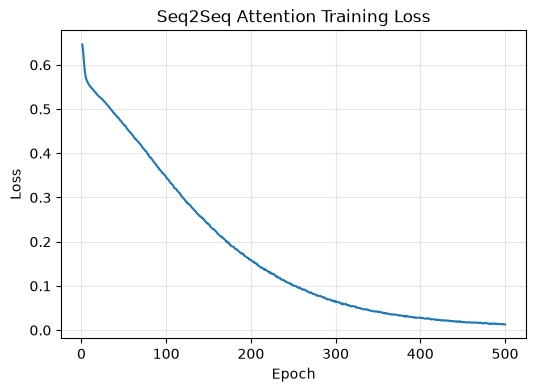

In [11]:
# 1. 超参数
embed_size, num_hiddens, num_layers, dropout = 32, 32, 2, 0.1
batch_size, num_steps = 64, 10
lr, num_epochs = 0.5, 500
device = get_device()

# 2. 加载数据
src_file_path = r'C:\Users\17934\Desktop\MachineLearning\Program\注意力机制\src.txt'
tgt_file_path = r'C:\Users\17934\Desktop\MachineLearning\Program\注意力机制\tgt.txt'
train_iter, src_vocab, tgt_vocab = load_data_nmt(batch_size, num_steps, src_file_path, tgt_file_path)

# 3. 构建模型
encoder = Seq2SeqEncoder(len(src_vocab), embed_size, num_hiddens, num_layers, dropout)
decoder = Seq2SeqAttentionDecoder(len(tgt_vocab), embed_size, num_hiddens, num_layers, dropout)
net = EncoderDecoder(encoder, decoder)

# 4. 训练
train_seq2seq(net, train_iter, lr, num_epochs, tgt_vocab, device)


In [19]:
# 5. 推理 + BLEU评估

# 改写英文
engs = [
    "Deep learning is a branch of machine learning built on artificial neural networks.",
    "The single artificial neuron calculates a weighted sum of its inputs.",
    "Dropout randomly disables part of neurons during training to stop overfitting.",
    "Pooling layers cut the spatial size of feature maps and retain vital information.",
    "Long short-term memory networks solve the vanishing gradient problem in long texts."
]
# 对应标准法语参考
fras = [
    "Le deep learning est une branche de l'apprentissage automatique construite sur des réseaux de neurones artificiels.",
    "Le neurone artificiel unique calcule une somme pondérée de ses entrées.",
    "Le dropout désactive au hasard une partie des neurones pendant l'entraînement pour stopper le surapprentissage.",
    "Les couches de pooling réduisent la taille spatiale des cartes de caractéristiques et conservent les informations essentielles.",
    "Les réseaux de mémoire à long terme à court terme résolvent le problème de disparition du gradient dans les longs textes."
]
net.eval()

for eng, fra in zip(engs, fras):
    trans, attn_seq = predict_seq2seq(net, eng, src_vocab, tgt_vocab, num_steps, device, True)
    print(f"{eng:12s} => {trans:18s} | BLEU: {bleu(trans, fra, k=2):.3f}")

Deep learning is a branch of machine learning built on artificial neural networks. => le deep learning est un sous-domaine de l'apprentissage automatique basé | BLEU: 0.283
The single artificial neuron calculates a weighted sum of its inputs. => un neurone artificiel unique calcule une somme pondérée de ses | BLEU: 0.809
Dropout randomly disables part of neurons during training to stop overfitting. => le surapprentissage se produit lorsqu'un modèle fonctionne bien sur les | BLEU: 0.000
Pooling layers cut the spatial size of feature maps and retain vital information. => les couches de pooling réduisent les dimensions spatiales des cartes | BLEU: 0.277
Long short-term memory networks solve the vanishing gradient problem in long texts. => les réseaux de neurones convolutifs sont particulièrement efficaces pour traiter | BLEU: 0.061


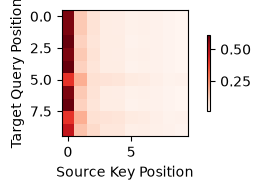

In [20]:
# 推理后得到 attn_seq：列表，每个元素 shape [1, src_len]
# 错误旧逻辑：attn_all = torch.cat([step[0] for step in attn_seq], dim=0)
# 正确写法
attn_list = []
for step in attn_seq:
    # step[0] → shape (1, src_len) 单个生成词对全部源词的注意力
    attn_list.append(step[0])

# 拼接后正确形状：[tgt_real_len, src_real_len]
# tgt_real_len = 真实生成单词数量（只有4个，不会50）
attn_matrix = torch.cat(attn_list, dim=0)

# 1. 裁源侧 padding
src_text = engs[-1]
src_tokens = src_text.split()
src_valid = len(src_tokens) + 1
attn_matrix = attn_matrix[:, :src_valid]

# 2. 裁目标侧多余padding行
# attn_seq 长度 = 真实生成词数量，直接取行数，没有多余50行
tgt_valid = len(attn_seq)
attn_matrix = attn_matrix[:tgt_valid, :]

# 四维 [1,1,Query_num,Key_num] Query=行(目标), Key=列(源)
heat_4d = attn_matrix.unsqueeze(0).unsqueeze(0)

# figsize 宽>高，横向画布，杜绝竖长条
show_heatmaps(
    heat_4d,
    xlabel="Source Key Position",
    ylabel="Target Query Position",
    figsize=(4, 2),
    cmap="Reds"
)